In [49]:
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    roc_curve
)
from sklearn.model_selection import train_test_split
import seaborn as sns

In [50]:
df = pd.read_csv('../data/processed_data.csv')
print("Dataset shape:", df.shape)

# Separate features and target
y_raw = df['Attrition'].values
X = df.drop(columns=['Attrition']).values
y = (y_raw == y_raw.max()).astype(int)
feature_names = df.drop(columns=['Attrition']).columns.tolist()

print(f"\nFeatures shape: {X.shape}")
print(f"Original class distribution (real data):")
print(f"  No Attrition (0): {np.sum(y == 0)}")
print(f"  Attrition    (1): {np.sum(y == 1)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nTrain: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")
print(f"Test class distribution (real, untouched):")
print(f"  No Attrition (0): {np.sum(y_test == 0)}")
print(f"  Attrition    (1): {np.sum(y_test == 1)}")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {X_train.shape[0]} samples")
print(f"  No Attrition (0): {np.sum(y_train == 0)}")
print(f"  Attrition    (1): {np.sum(y_train_resampled == 1)}")

Dataset shape: (1470, 37)

Features shape: (1470, 36)
Original class distribution (real data):
  No Attrition (0): 1232
  Attrition    (1): 238

Train: 1176 samples | Test: 294 samples
Test class distribution (real, untouched):
  No Attrition (0): 246
  Attrition    (1): 48

After SMOTE — Train: 1176 samples
  No Attrition (0): 986
  Attrition    (1): 986


In [51]:
X_train = np.array(X_train_resampled)
X_test = np.array(X_test)
y_train = np.array(y_train_resampled)
y_test = np.array(y_test)

# =========================
# 2️⃣ Standardize (สำคัญมาก)
# =========================

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

# Add bias term
X_train = np.c_[np.ones(X_train.shape[0]), X_train]
X_test = np.c_[np.ones(X_test.shape[0]), X_test]

# =========================
# 3️⃣ Define Logistic Model
# =========================

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_loss(y, y_hat):
    epsilon = 1e-9
    return -np.mean(
        y*np.log(y_hat+epsilon) +
        (1-y)*np.log(1-y_hat+epsilon)
    )

def train_logistic(X, y, lr=0.01, epochs=2000):
    m, n = X.shape
    weights = np.zeros(n)
    losses = []

    for i in range(epochs):
        z = np.dot(X, weights)
        y_hat = sigmoid(z)

        gradient = np.dot(X.T, (y_hat - y)) / m
        weights -= lr * gradient

        loss = compute_loss(y, y_hat)
        losses.append(loss)

    return weights, losses

In [52]:
weights, losses = train_logistic(X_train, y_train, lr=0.01, epochs=2000)

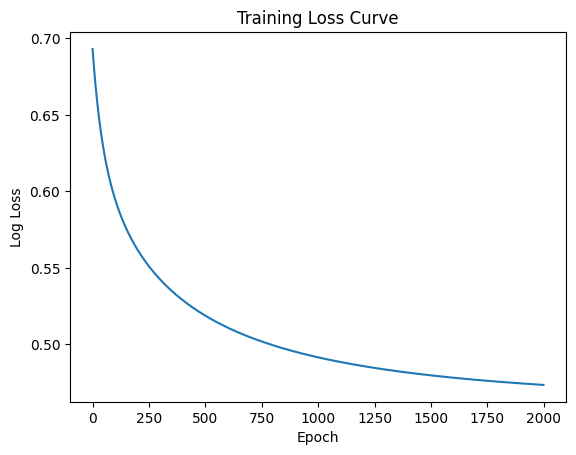

              precision    recall  f1-score   support

           0       0.93      0.63      0.76       246
           1       0.29      0.77      0.42        48

    accuracy                           0.66       294
   macro avg       0.61      0.70      0.59       294
weighted avg       0.83      0.66      0.70       294

ROC-AUC: 0.8104674796747968
Accuracy: 0.6564625850340136
specificity: 0.6341463414634146


In [53]:
plt.plot(losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.show()

# =========================
# 5️⃣ Predict
# =========================

z_test = np.dot(X_test, weights)
y_prob = sigmoid(z_test)

threshold = 0.4
y_pred = (y_prob >= threshold).astype(int)

# =========================
# 6️⃣ Evaluate
# =========================

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("specificity:", confusion_matrix(y_test, y_pred)[0, 0] / np.sum(confusion_matrix(y_test, y_pred)[0]))

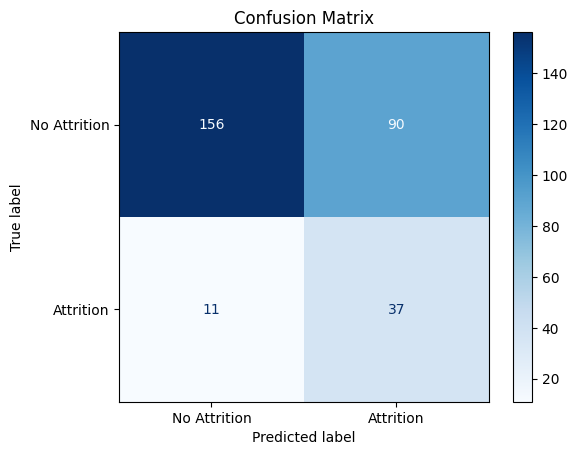

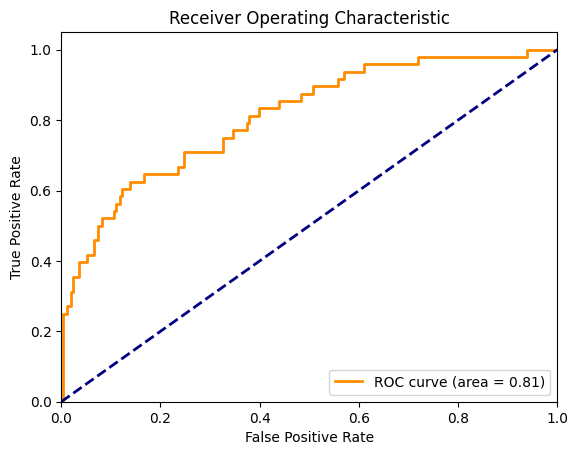

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_curve, auc

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Attrition', 'Attrition'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# ROC AUC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [55]:
from sklearn.linear_model import LogisticRegression

              precision    recall  f1-score   support

           0       0.94      0.66      0.78       246
           1       0.31      0.79      0.45        48

    accuracy                           0.68       294
   macro avg       0.63      0.73      0.61       294
weighted avg       0.84      0.68      0.72       294

ROC-AUC: 0.8242716802168022
Accuracy: 0.6836734693877551
specificity: 0.6626016260162602


Text(0.5, 1.0, 'Confusion Matrix (Logistic Regression)')

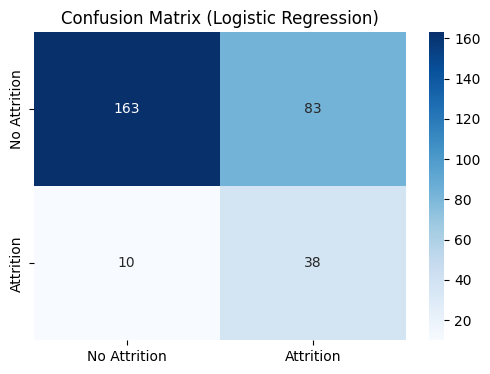

In [56]:
model = LogisticRegression(max_iter=2000, random_state=42)
model.fit(X_train, y_train)

# Predict
y_prob = model.predict_proba(X_test)[:,1]

threshold = 0.4
y_pred = (y_prob >= threshold).astype(int)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("specificity:", confusion_matrix(y_test, y_pred)[0, 0] / np.sum(confusion_matrix(y_test, y_pred)[0]))

plt.figure(figsize=(6, 4))  
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Attrition", "Attrition"], yticklabels=["No Attrition", "Attrition"])
plt.title("Confusion Matrix (Logistic Regression)")




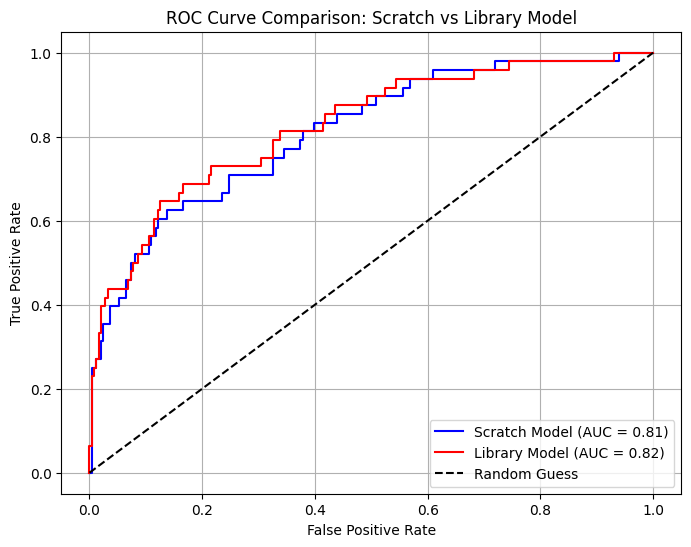

In [57]:
# Compute predictions for scratch model
z_test_scratch = np.dot(X_test, weights)
y_prob_scratch = sigmoid(z_test_scratch)

# Compute ROC for scratch model
fpr_scratch, tpr_scratch, _ = roc_curve(y_test, y_prob_scratch)
auc_scratch = auc(fpr_scratch, tpr_scratch)

# Compute predictions for sklearn model
y_prob_sklearn = model.predict_proba(X_test)[:, 1]

# Compute ROC for sklearn model
fpr_sklearn, tpr_sklearn, _ = roc_curve(y_test, y_prob_sklearn)
auc_sklearn = auc(fpr_sklearn, tpr_sklearn)

# Plot both ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr_scratch, tpr_scratch, label=f'Scratch Model (AUC = {auc_scratch:.2f})', color='blue')
plt.plot(fpr_sklearn, tpr_sklearn, label=f'Library Model (AUC = {auc_sklearn:.2f})', color='red')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison: Scratch vs Library Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()